# Тестовое задание — полное решение (код + ответы)
Ноутбук содержит все 18 вопросов: там, где нужен расчёт — код на pandas/scipy с результатом; там, где вопрос про интерпретацию графика или теорию — ответ и обоснование в markdown-ячейке (с самим графиком, если он нужен для ответа).

Источник данных: `Данные для тестового задания.xlsx` (листы «Данные об аудитории», «Данные АБ тестов», «Листеры»).

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

xls = pd.ExcelFile('Данные для тестового задания.xlsx')
aud = pd.read_excel(xls, 'Данные об аудитории')
ab = pd.read_excel(xls, 'Данные АБ тестов')
listeners = pd.read_excel(xls, 'Листеры')

aud['date'] = pd.to_datetime(aud['date'])
listeners['date'] = pd.to_datetime(listeners['date'])

print(aud.shape, ab.shape, listeners.shape)
aud.head()

(16814, 3) (2835, 4) (158, 6)


,date,user_id,view_adverts
0,2023-11-11,8c020470-8461-11ed-83d0-552e8cc749d6,13
1,2023-11-18,5875f070-7b92-11ee-a6fb-8b298e83f4f7,14
2,2023-11-29,3c2d27c0-4fd6-11eb-b89f-2ffb31b67dd6,21
3,2023-11-29,234a96d0-ad16-11ed-a2e6-793ddfeeba1f,23
4,2023-11-29,4d07c180-644f-11eb-879c-b7c02edf4f37,12


## Вопрос 1. Чему равен MAU продукта?
MAU — количество уникальных пользователей за весь ноябрь.

In [2]:
mau = aud['user_id'].nunique()
print('MAU =', mau)

MAU = 7639


**Ответ: 7639**

## Вопрос 2. Чему равен DAU?
Среднее количество уникальных активных пользователей в день за ноябрь.

In [3]:
daily_unique = aud.groupby(aud['date'].dt.date)['user_id'].nunique()
display(daily_unique)
print('Средний DAU =', round(daily_unique.mean(), 2))

date
2023-11-01    623
2023-11-02    649
2023-11-03    573
2023-11-04    343
2023-11-05    350
2023-11-06    660
2023-11-07    629
2023-11-08    600
2023-11-09    661
2023-11-10    583
2023-11-11    354
2023-11-12    377
2023-11-13    646
2023-11-14    687
2023-11-15    690
2023-11-16    639
2023-11-17    585
2023-11-18    412
2023-11-19    378
2023-11-20    711
2023-11-21    651
2023-11-22    608
2023-11-23    632
2023-11-24    595
2023-11-25    366
2023-11-26    372
2023-11-27    589
2023-11-28    610
2023-11-29    621
2023-11-30    620
Name: user_id, dtype: int64

Средний DAU = 560.47


**Ответ: 560** (точное значение 560,47)

## Вопрос 3. Retention 1-го дня для когорты 1 ноября
Берём пользователей, впервые появившихся в данных 1 ноября, и смотрим, какая доля из них вернулась 2 ноября.

In [4]:
first_seen = aud.groupby('user_id')['date'].min()
new_nov1 = first_seen[first_seen == pd.Timestamp('2023-11-01')].index
active_nov2 = set(aud.loc[aud['date'] == pd.Timestamp('2023-11-02'), 'user_id'])
retained = [u for u in new_nov1 if u in active_nov2]

print('Новых пользователей 1 ноября:', len(new_nov1))
print('Вернулись 2 ноября:', len(retained))
print('Retention D1 = {:.1%}'.format(len(retained) / len(new_nov1)))

Новых пользователей 1 ноября: 623
Вернулись 2 ноября: 166
Retention D1 = 26.6%


**Ответ: 26,6%**

## Вопрос 4. Интерпретация retention-кривых двух продуктов
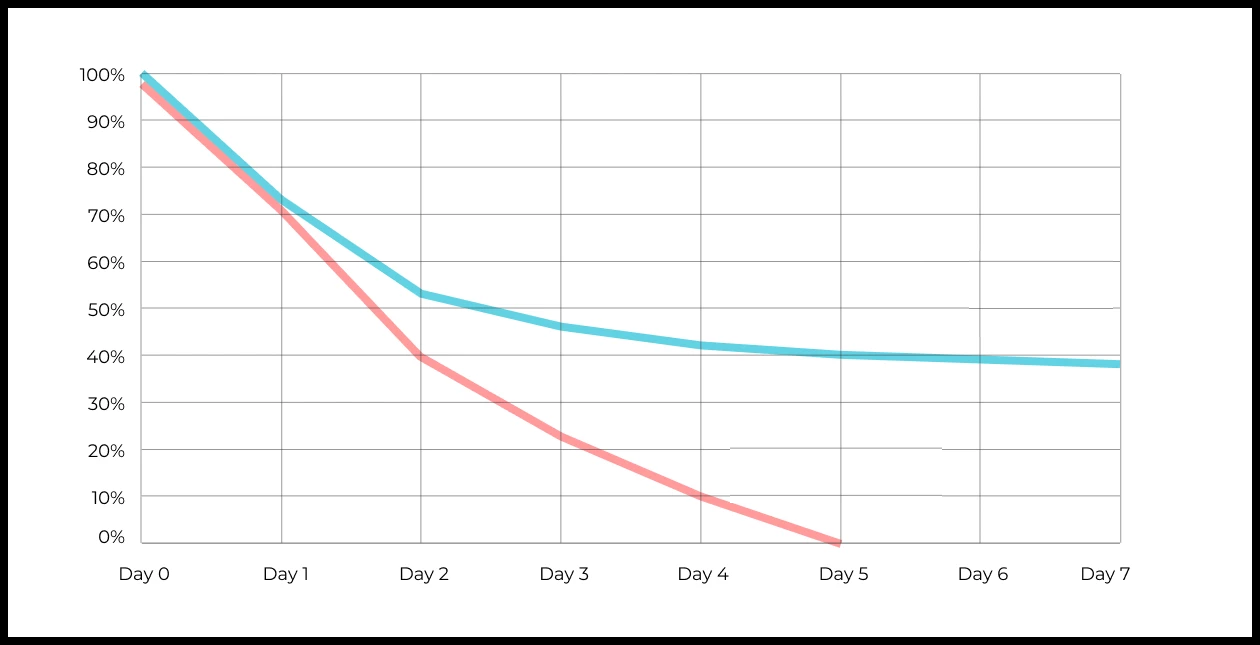

**Ответ:** голубая кривая стабилизируется на уровне ~40% начиная с 4–5 дня — признак здорового продукта с устойчивым ядром лояльных пользователей, которые продолжают возвращаться. Красная кривая, напротив, продолжает падать без остановки и к 5-му дню доходит до 0% — продукт полностью теряет всех пользователей, что указывает на серьёзную проблему с удержанием (слабый продуктовый опыт, отсутствие причин возвращаться, разовое использование). Несмотря на похожий старт и близкие показатели в 1-й день, дальше продукты кардинально расходятся — продукт с голубой кривой значительно устойчивее в долгосрочной перспективе.

## Вопрос 5. Конверсия в просмотр объявления
Доля пользователей с view_adverts > 0 хотя бы раз за месяц.

In [5]:
per_user_views = aud.groupby('user_id')['view_adverts'].sum()
total_users = per_user_views.shape[0]
viewed = (per_user_views > 0).sum()
print('Всего пользователей:', total_users)
print('Посмотрели хотя бы 1 объявление:', viewed)
print('Конверсия = {:.1%}'.format(viewed / total_users))

Всего пользователей: 7639
Посмотрели хотя бы 1 объявление: 3538
Конверсия = 46.3%


**Ответ: 46,3%**

## Вопрос 6. Среднее число просмотренных объявлений на пользователя

In [6]:
total_views = aud['view_adverts'].sum()
print('Всего просмотров объявлений за ноябрь:', total_views)
print('Среднее на ВСЕХ пользователей = {:.2f}'.format(total_views / total_users))
print('Среднее среди тех, кто хотя бы раз смотрел = {:.2f}'.format(per_user_views[per_user_views > 0].mean()))

Всего просмотров объявлений за ноябрь: 21914
Среднее на ВСЕХ пользователей = 2.87
Среднее среди тех, кто хотя бы раз смотрел = 6.19


**Ответ: 2,9** (в среднем на всех пользователей, включая тех, кто не смотрел рекламу)

## Вопрос 7. NPS
NPS = % сторонников − % критиков.

In [7]:
total = 2000
promoters, detractors, passives = 1200, 500, 300
nps = (promoters/total - detractors/total) * 100
print(f'NPS = {nps:.0f}%')

NPS = 35%


**Ответ: 35%**

## Вопрос 8. Три независимых A/B теста по ARPU
Для каждого эксперимента считаем t-тест Уэлча (параметрический) и тест Манна-Уитни (непараметрический, устойчив к выбросам/скошенности) на revenue между test и control.

In [8]:
for exp in sorted(ab['experiment_num'].unique()):
    sub = ab[ab['experiment_num'] == exp]
    c = sub.loc[sub['experiment_group'] == 'control', 'revenue']
    t = sub.loc[sub['experiment_group'] == 'test', 'revenue']

    tt = stats.ttest_ind(t, c, equal_var=False)
    mw = stats.mannwhitneyu(t, c, alternative='two-sided')

    print(f'--- Эксперимент {int(exp)} ---')
    print(f'control: n={len(c)}, mean={c.mean():.1f}, median={c.median():.1f}, доля нулей={ (c==0).mean():.1%}')
    print(f'test:    n={len(t)}, mean={t.mean():.1f}, median={t.median():.1f}, доля нулей={ (t==0).mean():.1%}')
    print(f'Welch t-test: p-value = {tt.pvalue:.4f}')
    print(f'Mann-Whitney: p-value = {mw.pvalue:.4f}')
    print()

--- Эксперимент 1 ---
control: n=465, mean=722.5, median=104.0, доля нулей=40.6%
test:    n=480, mean=665.7, median=104.0, доля нулей=40.2%
Welch t-test: p-value = 0.6890
Mann-Whitney: p-value = 0.7960

--- Эксперимент 2 ---
control: n=465, mean=704.7, median=74.0, доля нулей=40.6%
test:    n=480, mean=332.9, median=52.0, доля нулей=40.2%
Welch t-test: p-value = 0.0011
Mann-Whitney: p-value = 0.0085

--- Эксперимент 3 ---
control: n=465, mean=663.2, median=4.0, доля нулей=41.5%
test:    n=480, mean=998.7, median=156.0, доля нулей=40.2%
Welch t-test: p-value = 0.0603
Mann-Whitney: p-value = 0.0010



**Выводы и рекомендации:**

- **Эксперимент 1**: p ≈ 0,689 (t-тест) / 0,796 (Манна-Уитни) — значимых различий нет, изменение не повлияло на ARPU.
- **Эксперимент 2**: p ≈ 0,0011 (t-тест) / 0,0085 (Манна-Уитни) — статистически значимое ухудшение: ARPU в тесте упал почти вдвое (с ~705 до ~333). **Рекомендация: не выкатывать.**
- **Эксперимент 3**: p ≈ 0,060 (t-тест, на грани значимости) / 0,0010 (Манна-Уитни, значимо). Расхождение объясняется сильной скошенностью revenue (~40% нулей, большой разброс) — t-тест чувствителен к выбросам и здесь менее надёжен, а непараметрический тест показывает устойчивый рост (медиана выросла с 4 до 156). **Результат многообещающий**, но перед полной раскаткой стоит продлить тест или перепроверить устойчивыми к выбросам методами (bootstrap, лог-преобразование).

## Вопрос 9. Средний доход на пользователя (датасет «Листеры»)

In [9]:
per_user_rev = listeners.groupby('user_id')['revenue'].sum()
print('Уникальных пользователей:', per_user_rev.shape[0])
print('Средний суммарный доход на пользователя = {:.1f}'.format(per_user_rev.mean()))

Уникальных пользователей: 31
Средний суммарный доход на пользователя = 156.5


**Ответ: 156,4**

## Вопрос 10. Медиана возраста пользователя (датасет «Листеры»)

In [10]:
unique_age = listeners.drop_duplicates('user_id')['age']
print('Медиана возраста =', unique_age.median())
print('(для сравнения, среднее = {:.2f} — это вариант-ловушка, а не медиана)'.format(unique_age.mean()))

Медиана возраста = 28.0
(для сравнения, среднее = 27.94 — это вариант-ловушка, а не медиана)


**Ответ: 28** (27,93 в вариантах ответа — это среднее (mean), а не медиана — вариант-ловушка)

## Вопрос 11. Какой график лучше всего подходит для отображения разброса цен по разным магазинам?

**Ответ: Ящик с усами (box plot).** Он специально предназначен для сравнения разброса и распределения значений сразу между несколькими категориями (магазинами) на одном графике: показывает медиану, квартили и выбросы для каждой группы. Гистограмма тоже показывает разброс, но плохо подходит для сравнения сразу нескольких групп одновременно на одном графике.

## Вопрос 12. На каком графике бимодальное распределение?

№1:
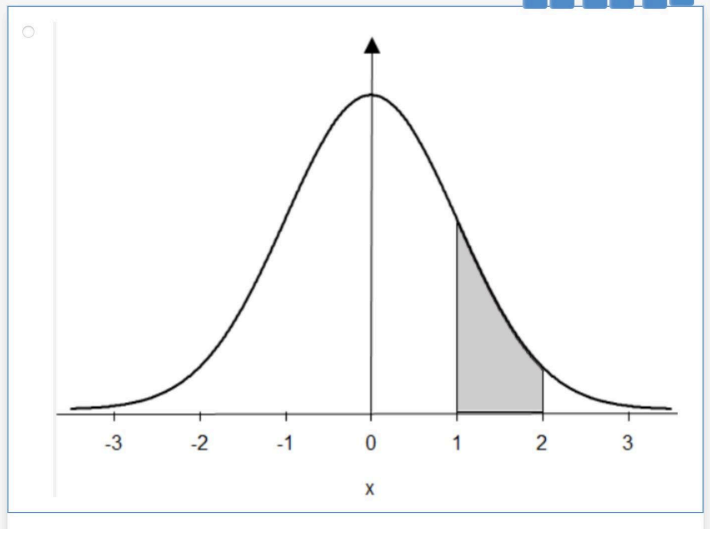

№2:
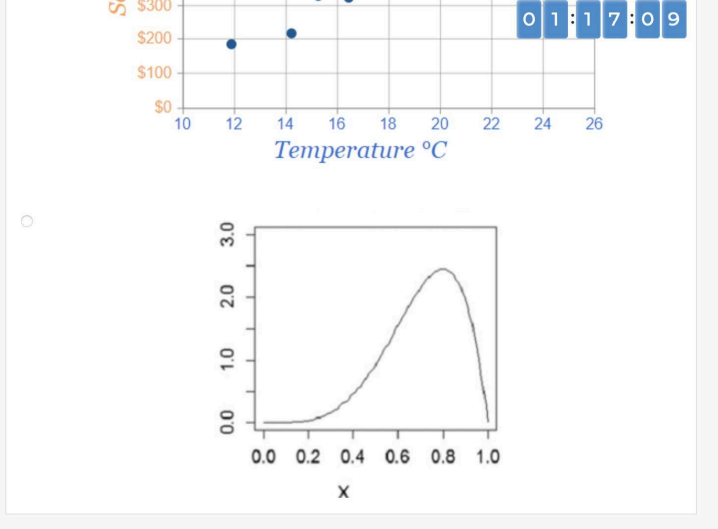

№3:
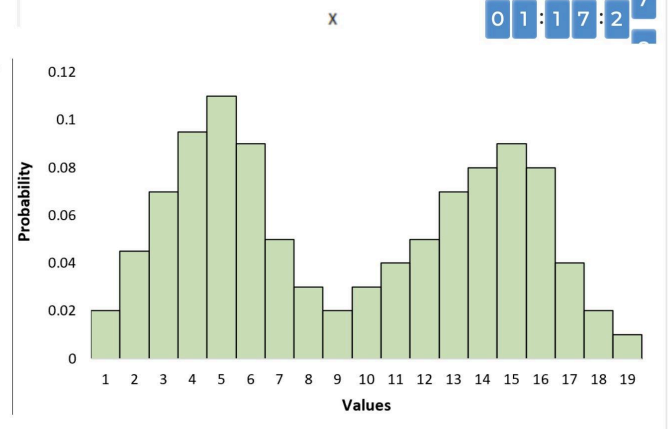

№4:
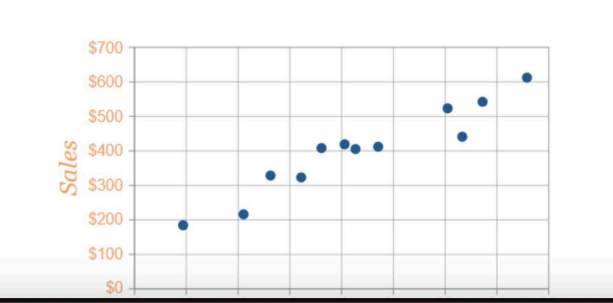

**Ответ: №3** — на графике два чётких пика (около значений 5 и 15) с провалом между ними — классический пример бимодального распределения. №1 — нормальное (одномодальное) распределение, №2 — скошенная одномодальная плотность, №4 — это вообще диаграмма рассеяния (scatter plot), а не распределение.

## Вопрос 13. Какая случайная величина имеет наибольшую дисперсию?

№1 (разброс примерно от −3 до 3):
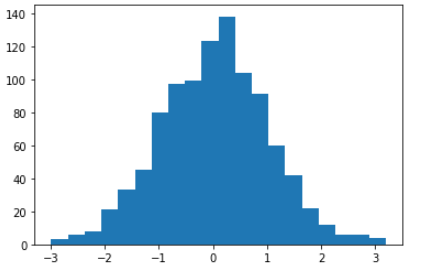

№2 (разброс примерно от 4 до 16):
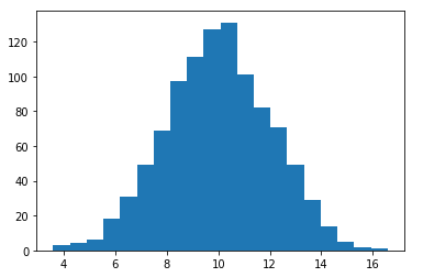

№3 (разброс примерно от −25 до 5):
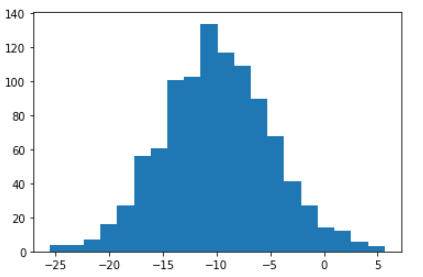

№4 (разброс примерно от −8 до 4):
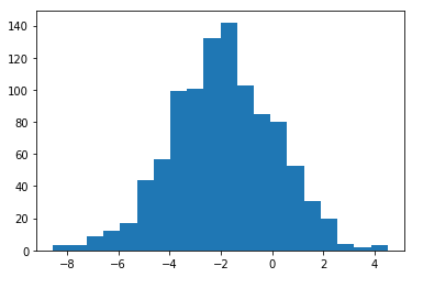

**Ответ: №3** — диапазон значений здесь заметно шире (~30 единиц), чем у остальных (№1 ≈ 6, №2 и №4 ≈ 12 единиц). Чем шире разброс данных вокруг среднего, тем больше дисперсия.

## Вопрос 14. На каком графике можно посчитать корреляцию?
*возможно несколько вариантов ответа*

№1 Scatter Plot:
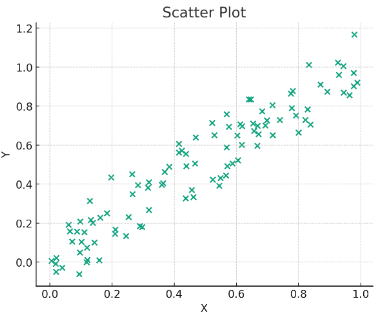

№2 Line Plot:
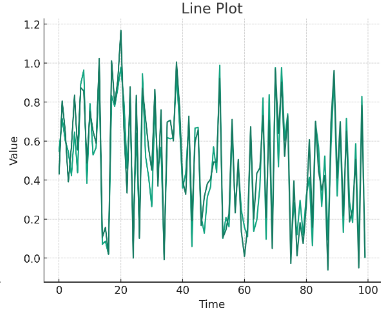

№3 Correlation Heatmap:
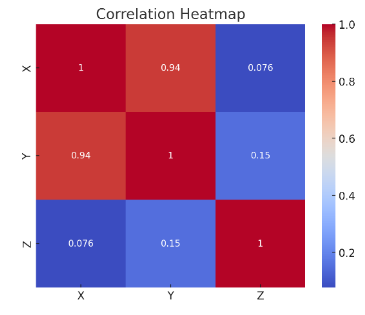

№4 Histogram & Density Plot:
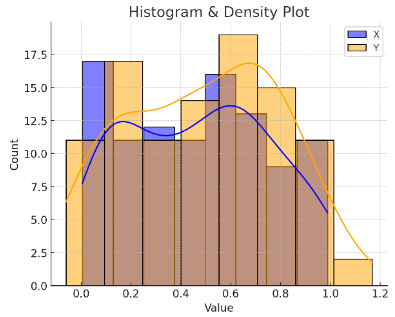

**Ответ: №1 и №3.** Диаграмма рассеяния наглядно показывает взаимосвязь между двумя переменными (по ней же можно оценить коэффициент корреляции), а тепловая карта корреляции прямо показывает численные значения корреляции. №2 показывает только одну переменную во времени, а №4 показывает распределения переменных по отдельности, а не связь между ними — оба не подходят для расчёта корреляции.

## Вопрос 15. Что значит p-value = 0.05?

**Ответ:** «Есть 5% вероятность случайно получить такой или ещё более экстремальный результат, если нулевая гипотеза верна» — это единственная корректная интерпретация p-value из предложенных. Остальные варианты — частые заблуждения (p-value не говорит напрямую ни о точности эксперимента, ни о вероятности верности гипотез, ни об отсутствии разницы).

## Вопрос 16. Метод для сравнения средних двух выборок из нормального распределения

**Ответ: t-тест** — используется для сравнения средних двух выборок, особенно при нормальном распределении данных.

## Вопрос 17. Как интерпретировать квартили?

**Ответ:** «Делят данные на четыре равные (по количеству наблюдений) части» — квартили разбивают отсортированный набор данных на 4 группы примерно по 25% наблюдений в каждой.

## Вопрос 18. Проверка A/B теста по конверсии в оплату
Вариант A (контроль): 100 047 501 посетитель, 1003 платежа.
Вариант B (тест): 100 001 055 посетителей, 1099 платежей.

In [11]:
nA, xA = 100_047_501, 1003
nB, xB = 100_001_055, 1099

pA, pB = xA/nA, xB/nB
p_pool = (xA+xB)/(nA+nB)
se = np.sqrt(p_pool*(1-p_pool)*(1/nA+1/nB))
z = (pB-pA)/se
pval = 2*(1-stats.norm.cdf(abs(z)))

print(f'Конверсия A = {pA:.4%}')
print(f'Конверсия B = {pB:.4%}')
print(f'Относительный прирост = {(pB-pA)/pA:.1%}')
print(f'z = {z:.3f}, p-value = {pval:.4f}')

Конверсия A = 0.0010%
Конверсия B = 0.0011%
Относительный прирост = 9.6%
z = 2.105, p-value = 0.0353


**Вывод и рекомендации:** формально разница статистически значима (p ≈ 0,035), но абсолютные величины (100+ млн «посетителей», конверсия ~0,1% в обеих группах) выглядят аномально для реального продукта — прежде чем подтверждать результат коллегам, стоит перепроверить методологию подсчёта посетителей/платежей на дубликаты, ботов и ошибки агрегации. Даже если цифры верны, при таких огромных выборках почти любая мелкая разница окажется «статистически значимой» — важно оценивать не только p-value, но и практическую значимость (абсолютная разница в конверсии здесь крайне мала — 0,01 процентного пункта). Не стоит спешить с раскаткой варианта B только на основании p-value, не подтвердив сначала целостность данных.